## Exploratory Data Analysis on Iris Dataset

**Objective**

I will perform Exploratory Data Analysis (EDA) on the Iris dataset to understand the features, explore relationships between them, and identify useful patterns and insights from the data.

**Dataset Information**

The Iris dataset contains **150 records** and **5 columns**:

* Sepal Length
* Sepal Width
* Petal Length
* Petal Width
* Species

The first four columns are numerical features, while **Species** represents the category of each flower.



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
path = "dataset/iris.csv"
raw =pd.read_csv(path)
df = raw.copy()

### 1. Basic Data Inspection

- Check the shape of the dataset.
- Look at the first few rows using `head()`.
- Check the data types of each column.
- Check the column names.

The purpose is to understand the basic structure of the dataset before starting EDA.


In [5]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


**All columns are listed below:**

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [7]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')

**Column Info:**

- The dataset contains both numerical and categorical variables.
- There are no null values present in any column.
- The dataset contains 4 numerical features and 1 categorical feature.
- The numerical features are `SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, and `PetalWidthCm`.
- `Species` is a categorical feature.


### 2. Data Quality

- Check for missing values.
- Check for duplicated rows.

These checks help me understand whether the data has basic quality issues before analysis.


**Missing Values:**

I expect that there will be no missing values. I will check this using `isna().sum()`.


In [8]:
df.isna().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

**Duplicate Rows**

Now I will check whether any duplicate rows are present in the dataset.


In [9]:
df.duplicated().sum()

np.int64(0)

### 3. Basic Statistics

I will use `describe()` to get a quick summary of the numerical features, such as count, mean, standard deviation, minimum, maximum, and quartiles.

These statistics give me an initial understanding of the data, but I need visual analysis to understand the distributions more deeply.


In [10]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


### 4. Feature Understanding

Now I will understand each feature individually using **Univariate Analysis**.


#### 1. Univariate Analysis

In univariate analysis, I analyze **one variable at a time**.

For numerical features, I mainly want to understand:
- the basic statistics
- the distribution
- the skewness
- whether potential outliers are present

For categorical features, I mainly want to understand:
- the categories present
- the frequency of each category
- whether the categories are balanced or imbalanced


**SepalLengthCm**

In [11]:
df["SepalLengthCm"].describe()

count    150.000000
mean       5.843333
std        0.828066
min        4.300000
25%        5.100000
50%        5.800000
75%        6.400000
max        7.900000
Name: SepalLengthCm, dtype: float64

The basic statistics give me some information, but I am not able to draw a strong conclusion about the shape of the data from them alone. I need to check the distribution for a deeper understanding.


Now I will check the distribution of the `SepalLengthCm` column.


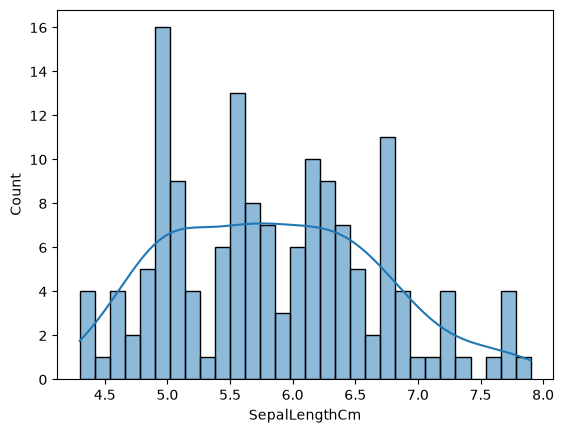

In [12]:
sns.histplot(x="SepalLengthCm",
             data=df,bins=30,
             kde=True);

I can see that the distribution of `SepalLengthCm` is approximately normal with a little right skew. I need to check how much skewness is present in the `SepalLengthCm` feature.


In [13]:
df["SepalLengthCm"].skew()

np.float64(0.3149109566369728)

I expected it to be approximately normal with a little right skew. The skewness is around **0.31**, which indicates a small positive (right) skew.


Okay, I checked the distribution. Now I will check whether any potential outliers are present. For this, I need to draw a boxplot.


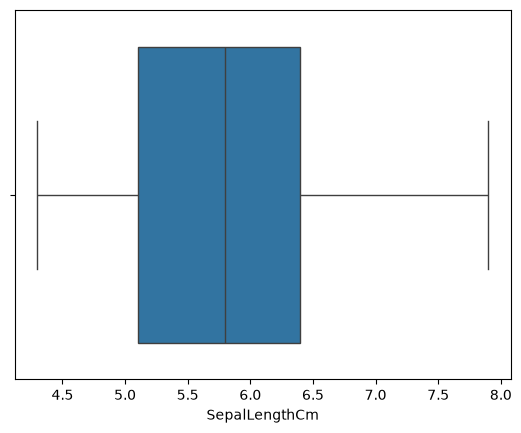

In [14]:
sns.boxplot(x="SepalLengthCm",
            data=df);

The boxplot suggests that there are no potential outliers present in `SepalLengthCm`.


**SepalWidthCm**

Okay, first I need to check the basic statistics.


In [15]:
df["SepalWidthCm"].describe()

count    150.000000
mean       3.054000
std        0.433594
min        2.000000
25%        2.800000
50%        3.000000
75%        3.300000
max        4.400000
Name: SepalWidthCm, dtype: float64

The basic statistics do not give me a strong conclusion. For a deeper understanding, let me check the distribution of `SepalWidthCm`.


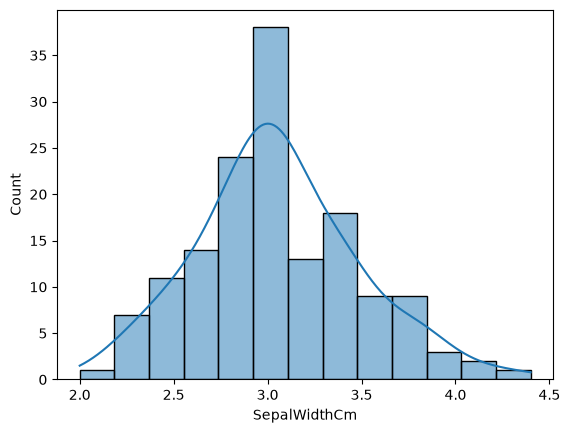

In [16]:
sns.histplot(x="SepalWidthCm",
             data=df,
             kde=True);

The distribution of `SepalWidthCm` shows that most values are around **3.0 cm**. The shape of the distribution gives me an idea about its form, but I also need to check the skewness to understand whether it is symmetric or skewed.


In [17]:
df["SepalWidthCm"].skew()

np.float64(0.3340526621720866)

The KDE looks roughly bell-shaped, but I need to use the skewness value to quantify the asymmetry. The skewness is approximately **0.33**, which indicates a slight right skew in this dataset.

Now I understand the distribution better. Let me check whether any potential outliers are present.


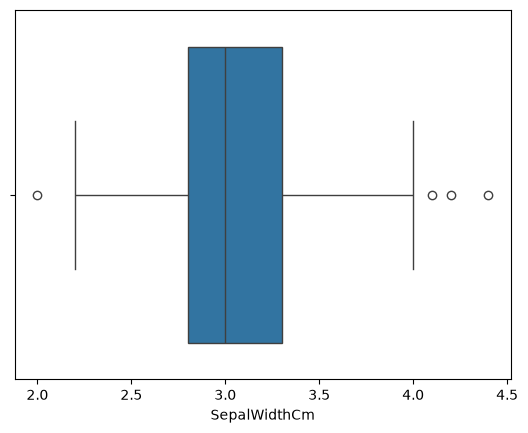

In [18]:
sns.boxplot(x="SepalWidthCm",
            data=df);

The boxplot suggests that there are some potential outliers. After investigating them further and understanding why they occur, I can decide what should be done with these values. I should not remove outliers automatically.


**PetalLengthCm**

Since `PetalLengthCm` is a numerical feature, I need to check its basic statistics first.


In [19]:
df["PetalLengthCm"].describe()

count    150.000000
mean       3.758667
std        1.764420
min        1.000000
25%        1.600000
50%        4.350000
75%        5.100000
max        6.900000
Name: PetalLengthCm, dtype: float64

From the basic statistics, I am not able to derive a strong conclusion about the shape of the data. For a deeper understanding, I need to check the distribution.


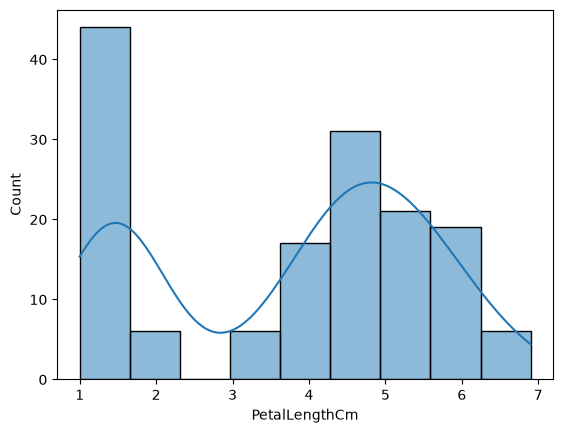

In [20]:
sns.histplot(x="PetalLengthCm",
             data=df,
             kde=True);

The distribution of `PetalLengthCm` appears to be **bimodal**, with distinct groups of values. There is a clear difference between the two groups. It is possible that these groups are related to different species, so I need to investigate this further using the `Species` feature.

Skewness will not explain the two groups very well here, so I will focus on the distribution and then check for potential outliers.


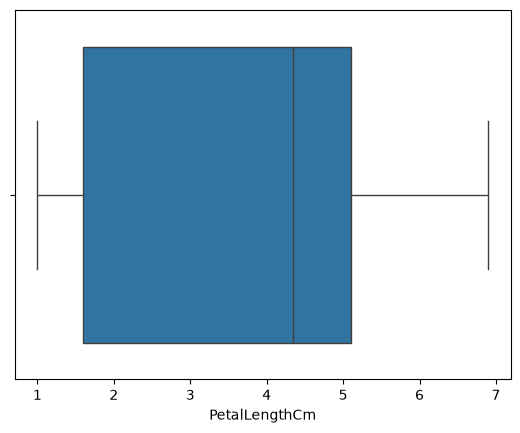

In [21]:
sns.boxplot(x="PetalLengthCm",
            data=df);

The boxplot suggests that there are no potential outliers in `PetalLengthCm`.


**PetalWidthCm**

Since `PetalWidthCm` is a numerical feature, I need to check its basic statistics first.


In [22]:
df["PetalWidthCm"].describe()

count    150.000000
mean       1.198667
std        0.763161
min        0.100000
25%        0.300000
50%        1.300000
75%        1.800000
max        2.500000
Name: PetalWidthCm, dtype: float64

From the basic statistics, I am not able to make a strong conclusion because the values are small and the summary statistics alone do not show the shape of the distribution. I need to check the distribution for a deeper understanding.


<Axes: xlabel='PetalWidthCm', ylabel='Count'>

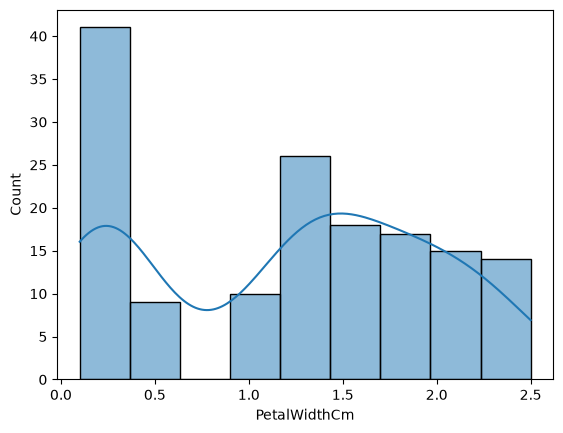

In [23]:
sns.histplot(x="PetalWidthCm",
             data=df,
             kde=True)

The distribution of `PetalWidthCm` also appears to be **bimodal**. We can see a gap between the two groups, so I need to investigate this further, possibly using the `Species` feature.

Now let me check for potential outliers.


<Axes: xlabel='PetalWidthCm'>

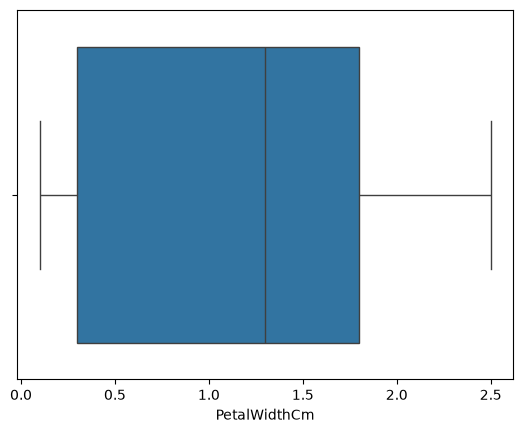

In [24]:
sns.boxplot(x="PetalWidthCm",
            data=df)

The boxplot suggests that there are no potential outliers in `PetalWidthCm`.


**Species**

Now I will analyze the categorical feature `Species`.


Since `Species` is a categorical feature, I need to check the frequency of each category.

For categorical variables, I want to know:
- how many categories are present
- how many observations belong to each category
- whether the categories are balanced or imbalanced


In [25]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

**Category Proportion**

Frequency tells me the number of observations in each category. I can also look at the proportion to understand what percentage of the dataset each category represents.


In [26]:
df["Species"].value_counts(normalize=True) * 100


Species
Iris-setosa        33.333333
Iris-versicolor    33.333333
Iris-virginica     33.333333
Name: proportion, dtype: float64

<Axes: xlabel='Species', ylabel='count'>

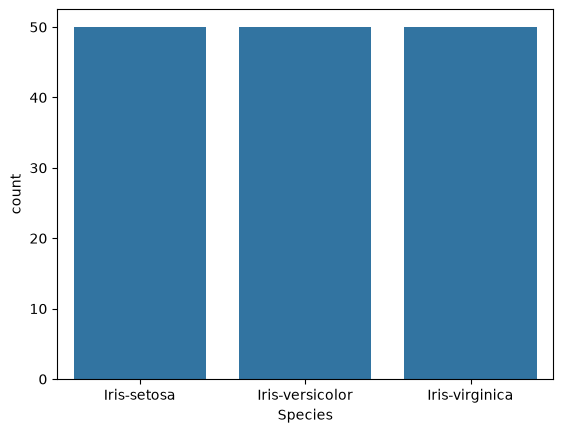

In [27]:
sns.countplot(x="Species",
              data=df)

The distribution of `Species` shows that the three categories are equally distributed.

So, the target/category variable is **balanced** in this dataset.

To understand a categorical variable, frequency/counts are more useful than numerical statistics such as mean or standard deviation.


### Univariate Analysis — What I Learned

For **numerical features**, my basic workflow is:

1. Check basic statistics using `describe()`.
2. Check the distribution using a histogram/KDE plot.
3. Check skewness when it helps describe the shape.
4. Check potential outliers using a boxplot.
5. If the distribution has multiple peaks or groups, investigate whether another variable (such as `Species`) explains them.

For **categorical features**:

1. Check the categories present.
2. Check the frequency of each category using `value_counts()`.
3. Check proportions when I want to understand whether the categories are balanced or imbalanced.

The main goal of univariate analysis is to understand each variable **individually before studying relationships between variables**.

#### Bivaraite Analysis
since data conatins 1 categorical and 4 Numerical features are present. so 
we can comapre onlt two ways
- numerical - Numerical
- numerical - Categorical

okay let me strart from numerical numerical 
SepalWidthCm and SepalLengthCm .. okay im curious what could be their realtionship.. for checking realtionship scatterplot may help

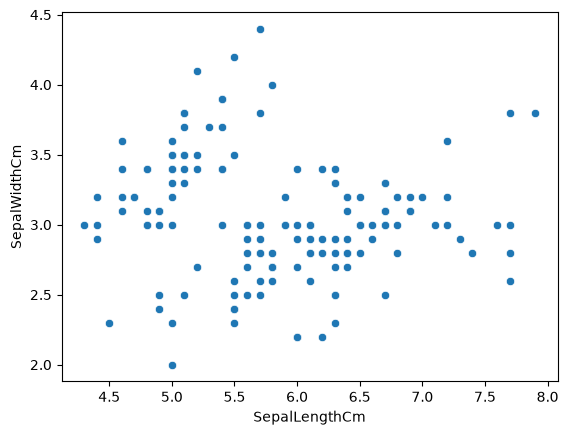

In [31]:
sns.scatterplot(x="SepalLengthCm",
                y='SepalWidthCm',
                data=df);

scatter plot of SepalWidthCm and SepallengthCm showing some culter. could be possibility they are from diffrent diffrent group . we need to inveigate further with species. graph is not showing any linear realtion.. let me check correlation btw these feature it will give me mathematcial idea

In [32]:
df[["SepalWidthCm","SepalLengthCm"]].corr()

,SepalWidthCm,SepalLengthCm
SepalWidthCm,1.000000,-0.109369
SepalLengthCm,-0.109369,1.000000


i expected that since it is making cluster it has little neagtive correlation. 

now let me check between SepalLengthCm and PetalLengthCm

SepalLengthCm vs PetalLengthCm

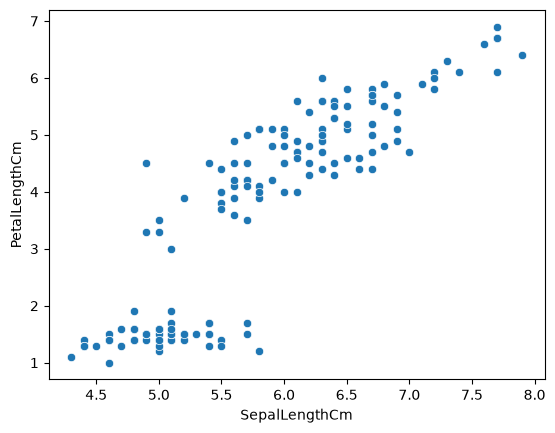

In [35]:
sns.scatterplot(x="SepalLengthCm",
                y="PetalLengthCm",
                data=df);

okay now i can see that there are sort of linear realtion of these feature .. i need to check mathermtically

In [38]:
df[["PetalLengthCm","SepalLengthCm"]].corr()

,PetalLengthCm,SepalLengthCm
PetalLengthCm,1.000000,0.871754
SepalLengthCm,0.871754,1.000000


yes i expected that there are very strong realtion btw these features

	               SepalLengthCm vs PetalWidthCm

<Axes: xlabel='SepalLengthCm', ylabel='PetalWidthCm'>

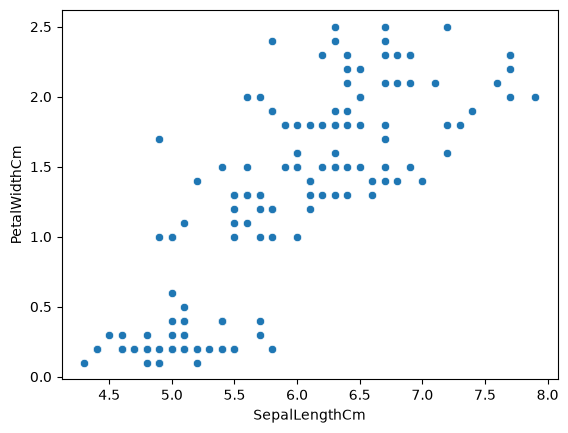

In [41]:
sns.scatterplot(x="SepalLengthCm",
                y="PetalWidthCm",
                data=df)

i can see there are some linear relationship .. we need to check mathematcally

In [42]:
df[["PetalWidthCm","SepalLengthCm"]].corr()

,PetalWidthCm,SepalLengthCm
PetalWidthCm,1.000000,0.817954
SepalLengthCm,0.817954,1.000000


yes. SepalLengthCm and PetalWidthCm has very high correlation btw these columns

<Axes: xlabel='SepalWidthCm', ylabel='PetalLengthCm'>

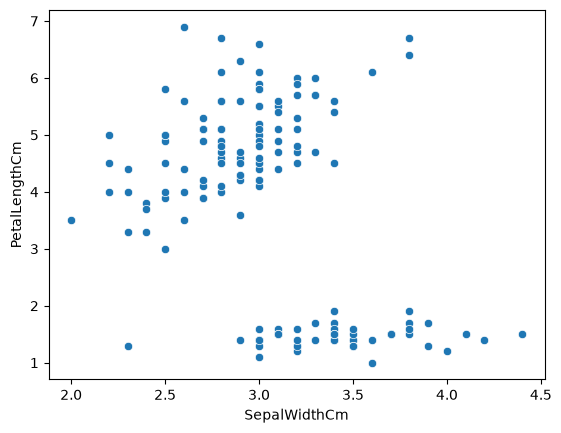

In [44]:
sns.scatterplot(x="SepalWidthCm",
                y="PetalLengthCm",
                data=df)